# Week 2 Practice Tutorial: training a one-hidden-layer ReLU network from scratch

**MATH3881/5881 — Statistical Machine Learning Theory**

This notebook is the computational companion to the Week 2 Theory Tutorial. We will *train* one-hidden-layer ReLU networks from scratch by gradient descent on two problems:

1. **XOR classification** (companion to Theory Problem 1, where the weights were *given* to you).
2. **Approximating $\sin(\pi x)$** (companion to Theory Problem 2, where we counted linear pieces).

In each case we will look beyond the loss curve to *what the network learned to do*. We use only **numpy** and **matplotlib**.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4)

## 1. The one-hidden-layer ReLU network and its gradients

For input $x \in \mathbb{R}^p$ and a single output $\hat y \in \mathbb{R}$, the network is
$$z^{[1]} = W^{[1]} x + b^{[1]}, \qquad a^{[1]} = \sigma_{\text{ReLU}}(z^{[1]}), \qquad \hat y \;=\; (W^{[2]})^\top a^{[1]} + b^{[2]}.$$

We will train by gradient descent on the mean squared error $\tfrac{1}{n}\sum_j (\hat y_j - y_j)^2$. The gradient formulas come from the chain rule (Week 3 will derive them properly as backpropagation). You do not need to redo the derivation here; just understand the shape of the code.

In [2]:
def relu(z):
    return np.maximum(0.0, z)

def forward(X, W1, b1, W2, b2):
    # Forward pass. X has shape (n, p), W1 (N1, p), b1 (N1,), W2 (N1,), b2 (1,).
    z1 = X @ W1.T + b1                     # (n, N1)
    a1 = relu(z1)                          # (n, N1)
    yhat = a1 @ W2 + b2                    # (n,)
    return yhat, (z1, a1)

def mse(yhat, y):
    return float(np.mean((yhat - y) ** 2))

def gradients(X, y, W1, b1, W2, b2):
    # Return gradients of MSE with respect to (W1, b1, W2, b2).
    n = len(y)
    yhat, (z1, a1) = forward(X, W1, b1, W2, b2)
    err = (2.0 / n) * (yhat - y)            # (n,)

    g_W2 = a1.T @ err                       # (N1,)
    g_b2 = float(np.sum(err))
    relu_mask = (z1 > 0).astype(float)      # (n, N1)
    dL_dz1 = (err[:, None] * W2[None, :]) * relu_mask    # (n, N1)
    g_W1 = dL_dz1.T @ X                     # (N1, p)
    g_b1 = np.sum(dL_dz1, axis=0)           # (N1,)
    return g_W1, g_b1, g_W2, g_b2

def init_params(p, N1, seed, scale=1.0):
    # Initialise. For 1-D input we spread biases so each ReLU kink lies in the
    # interval [-1, 1]; for higher-dim input we use small Gaussians.
    rng = np.random.default_rng(seed)
    if p == 1:
        xi = rng.uniform(-1, 1, N1)
        W1 = rng.choice([-1.0, 1.0], size=N1)[:, None] * rng.uniform(0.5, 2.0, N1)[:, None] * scale
        b1 = (-W1[:, 0] * xi).copy()
        W2 = rng.normal(0, 1.0 / np.sqrt(N1), N1)
        b2 = np.array([0.0])
    else:
        W1 = rng.normal(0, 0.5 * scale, size=(N1, p))
        b1 = np.zeros(N1)
        W2 = rng.normal(0, 0.5 * scale / np.sqrt(N1), size=N1)
        b2 = np.array([0.0])
    return W1, b1, W2, b2

def train(X, y, N1, lr=0.05, n_iter=5000, seed=0):
    p = X.shape[1]
    W1, b1, W2, b2 = init_params(p, N1, seed)
    losses = []
    for t in range(n_iter):
        g_W1, g_b1, g_W2, g_b2 = gradients(X, y, W1, b1, W2, b2)
        W1 -= lr * g_W1
        b1 -= lr * g_b1
        W2 -= lr * g_W2
        b2 -= lr * g_b2
        losses.append(mse(forward(X, W1, b1, W2, b2)[0], y))
    return (W1, b1, W2, b2), np.array(losses)

## Problem 1: training a ReLU MLP to learn XOR

In **Theory Problem 1** you were *given* weights $W^{[1]}, b^{[1]}, W^{[2]}, b^{[2]}$ for a 1-hidden-layer ReLU network that solves XOR with $N_1 = 2$ hidden units. Here, gradient descent has to *find* such weights from random initialisation.

### 1.1 The XOR data

The dataset is the four binary inputs with their XOR labels:
| sample $i$ | $x^{(i)}$ | $y^{(i)}$ |
|---|---|---|
| 1 | $(0, 0)$ | $0$ |
| 2 | $(0, 1)$ | $1$ |
| 3 | $(1, 0)$ | $1$ |
| 4 | $(1, 1)$ | $0$ |

So $n = 4$ training samples and $p = 2$ input features.

> **A natural question: would more samples ($n$ larger) help?** XOR is only defined at those four points; there is no "extra data" hiding anywhere. The reason training is sometimes hard here is not data scarcity, it is that with $N_1 = 2$ hidden units gradient descent can get stuck in a state where one of the two hidden units outputs $0$ for *every* training input. Once that happens, the gradient with respect to that unit's weights is also $0$ (because the ReLU is in its flat region), so the unit never wakes up. More training samples cannot fix this; widening the network can, because the extra hidden units make it very unlikely that *all* of them are stuck at the same time. In real applications data is noisy, and more samples genuinely help by reducing variance in the gradient and improving generalisation. For XOR with deterministic labels the bottleneck is optimisation, not data.

In [3]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)
n, p = X_xor.shape
print(f"X shape: {X_xor.shape}   ->   n = {n} samples, p = {p} features")
print("inputs:\n", X_xor)
print("labels:", y_xor)

X shape: (4, 2)   ->   n = 4 samples, p = 2 features
inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
labels: [0. 1. 1. 0.]


### 1.2 A single training run with $N_1 = 4$

We start with a comfortably-overparametrised width $N_1 = 4$ and one random seed. The cell below trains the network and shows the loss curve plus the learned decision surface.

final loss: 0.000000
predictions: [-0.  1.  1. -0.]
labels:      [0. 1. 1. 0.]


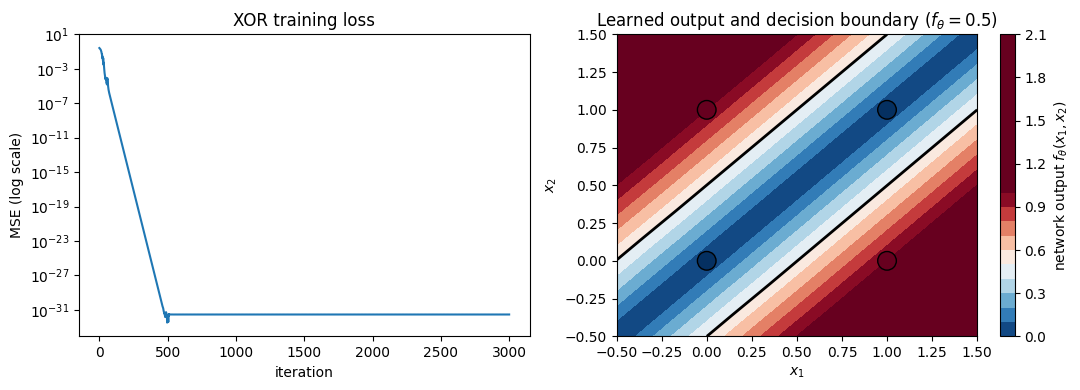

In [4]:
params, losses = train(X_xor, y_xor, N1=4, lr=0.5, n_iter=3000, seed=1)
yhat, _ = forward(X_xor, *params)
print(f"final loss: {losses[-1]:.6f}")
print("predictions:", np.round(yhat, 3))
print("labels:     ", y_xor)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(losses); ax[0].set_yscale("log")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("MSE (log scale)")
ax[0].set_title("XOR training loss")

# Learned output across the input plane, with the decision boundary overlaid
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
preds = forward(grid, *params)[0].reshape(xx.shape)
im = ax[1].contourf(xx, yy, preds, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
ax[1].contour(xx, yy, preds, levels=[0.5], colors="black", linewidths=2)
ax[1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, edgecolor="k", s=180, cmap="RdBu_r")
plt.colorbar(im, ax=ax[1], label=r"network output $f_\theta(x_1,x_2)$")
ax[1].set_xlabel(r"$x_1$"); ax[1].set_ylabel(r"$x_2$")
ax[1].set_title("Learned output and decision boundary ($f_\\theta = 0.5$)")
plt.tight_layout(); plt.show()

### 🎯 Task 1: does the minimal architecture actually train?

The Theory Tutorial used $N_1 = 2$ hidden units, the bare minimum that *can* compute XOR. Question: does gradient descent reliably *find* such a solution?

**Your task.** For each width $N_1 \in \{2, 4\}$ and each random seed $s = 0, 1, \ldots, 19$, train an XOR network with `train(X_xor, y_xor, N1=N1, lr=0.5, n_iter=3000, seed=s)`. Count how many of the $20$ runs end with final MSE below $0.01$ (i.e.\ XOR is essentially solved). Plot the histogram of final losses for $N_1 = 2$ and for $N_1 = 4$ side by side. **Explain what you see in one or two sentences.**

In [7]:
# DONE: write a helper success_rate(N1) that trains for n_seeds = 20 seeds
# with train(X_xor, y_xor, N1=N1, lr=0.5, n_iter=3000, seed=s) and returns
# (array of final losses, count of successes with final loss < 0.01).
# Then call it for N1 = 2 and N1 = 4, print success counts, and plot histograms
# of the final losses side by side. Explain what you see in a markdown cell.

def success_rate(N1):
  loss_threshold = 0.01
  losses_below_threshold = 0
  for s in range(20):
    params, losses = train(X_xor, y_xor, N1=N1, lr=0.5, n_iter=3000, seed=s)
    if losses[-1] < loss_threshold:
      losses_below_threshold += 1

  return losses_below_threshold / 20


print(success_rate(2))
print(success_rate(4))
# The wider neural network is less likely to be "stuck" with a random initialised parameter
# In other words, wider neural networks are more tolerant in some sense to local extrema

0.1
0.55


## Problem 2: approximating $\sin(\pi x)$, and seeing what each ReLU does

In **Theory Problem 2** you showed that a one-hidden-layer ReLU network is a piecewise-linear function with at most $N + 1$ linear pieces, and concluded the univariate Universal Approximation Theorem for ReLU networks. Here we train such a network on a smooth target and *see* the piecewise-linear structure of the learned approximation.

### 2.1 The target and the training data

$$f^\star(x) = \sin(\pi x), \qquad x \in [-1, 1].$$

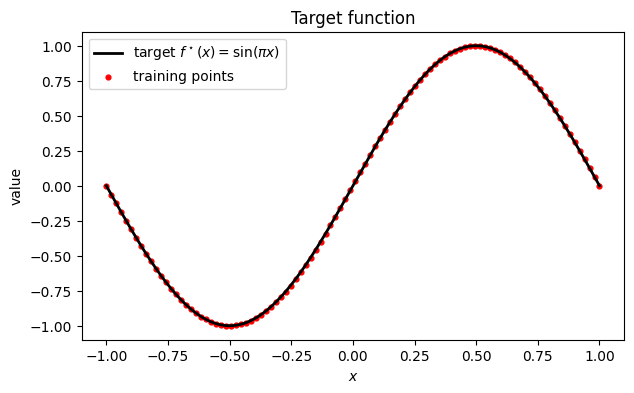

In [8]:
def target(x):
    return np.sin(np.pi * x)

n_train = 100
x_train = np.linspace(-1, 1, n_train)
y_train = target(x_train)

x_plot = np.linspace(-1, 1, 400)
y_plot = target(x_plot)

plt.plot(x_plot, y_plot, "k-", lw=2, label=r"target $f^\star(x) = \sin(\pi x)$")
plt.scatter(x_train, y_train, s=12, color="red", label="training points")
plt.xlabel("$x$"); plt.ylabel("value")
plt.title("Target function")
plt.legend(); plt.show()

### 2.2 A single training run with $N = 10$

The same `train` function works for this 1-D regression problem (it picked up that $p = 1$ and used a sensible initialisation).

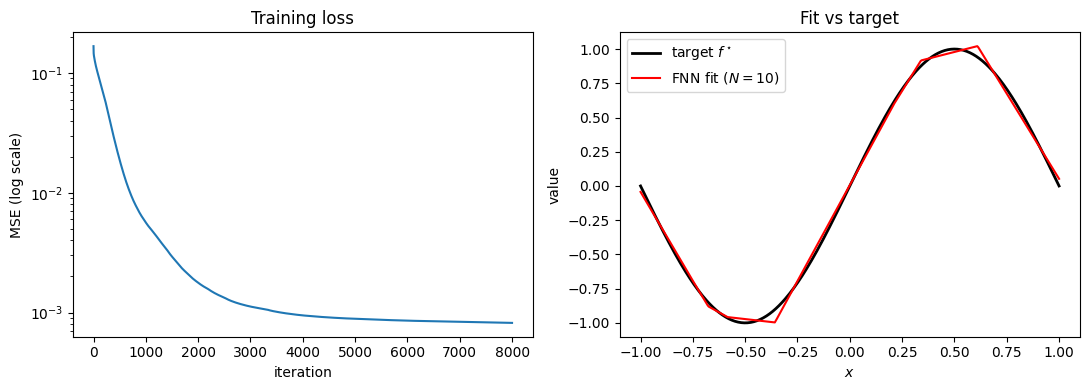

In [10]:
X1 = x_train[:, None]                                # shape (n, 1)
params_sin, losses_sin = train(X1, y_train, N1=10, lr=0.05, n_iter=8000, seed=2)

yhat_plot, _ = forward(x_plot[:, None], *params_sin)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(losses_sin); ax[0].set_yscale("log")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("MSE (log scale)")
ax[0].set_title("Training loss")

ax[1].plot(x_plot, y_plot,    "k-", lw=2,   label=r"target $f^\star$")
ax[1].plot(x_plot, yhat_plot, "r-", lw=1.5, label=f"FNN fit ($N=10$)")
ax[1].set_xlabel("$x$"); ax[1].set_ylabel("value")
ax[1].set_title("Fit vs target")
ax[1].legend()
plt.tight_layout(); plt.show()

### 🎯 Task 2: dissect what each hidden unit learned

The structural insight from Theory Problem 2 is that the trained network is

$$\hat f(x) \;=\; \underbrace{\sum_{i=1}^{N} \alpha_i\,\sigma_{\text{ReLU}}(w_i x + b_i)}_{\text{individual ReLU contributions}} \;+\; c.$$

**Your task.** For the trained network from Section 2.2, plot:

1. The target $f^\star$ and the network's fit $\hat f$ on the same axes (in black and red).
2. Each individual contribution $\alpha_i\,\sigma_{\text{ReLU}}(w_i x + b_i)$ as a separate thin coloured curve, on the same axes.

You should see $N$ piecewise-linear ramps that, when summed, reproduce the target. **In one or two sentences, comment on where the slope-change points $x_i^\star = -b_i / w_i$ end up after training and what each ReLU is "responsible" for.**

(Useful: $W^{[1]}$ has shape $(N, 1)$ so each weight $w_i$ is `W1[i, 0]`, and `b1[i]` is the corresponding bias.)

(array([[-2.03275866],
       [ 1.82039456],
       [-1.9253829 ],
       [-0.98909913],
       [ 1.61509594],
       [-0.89224802],
       [ 1.1795294 ],
       [ 1.80696415],
       [ 1.59954887],
       [-1.04938711]]), array([-0.72765335,  1.23096387,  0.65494274, -0.98949149, -0.98593617,
        0.89227055,  0.90629907,  1.80700088,  0.93560477,  0.21951884]), array([ 1.46443858,  0.92189068, -1.07840506, -0.53474367, -1.78106887,
        0.63872978,  0.06063214, -0.81458125,  0.42548558, -0.32338127]), array([0.0985971]))


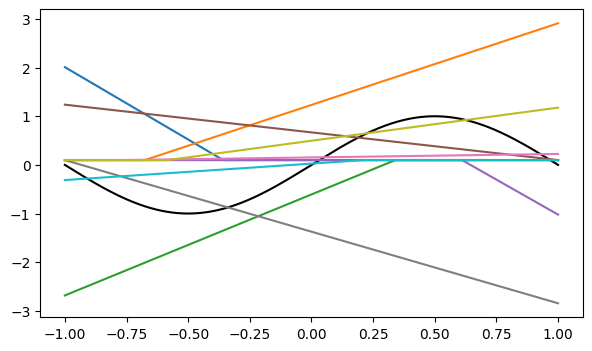

In [17]:
# TODO: from the trained params (W1, b1, W2, b2) of Section 2.2:
#   1. Compute each individual contribution alpha_i * ReLU(w_i x + b_i) on x_plot.
#   2. Plot the target f* (black), the FNN fit (red), and the N individual
#      contributions (thin coloured curves) on the same axes.
#   3. Print the slope-change points x_i* = -b_i / w_i.
# Then write a one- or two-sentence comment in a markdown cell describing what
# each ReLU is "responsible" for.

W1, b1, W2, b2 = params_sin
print(params_sin)

fig, ax = plt.subplots()
ax.plot(x_plot, y_plot, "k-")

for k in range(W1.shape[0]):
  ax.plot(x_plot, W2[k]*relu(W1[k, 0] * x_plot + b1[k]) + b2)


## Discussion

What you saw in the two problems:

- **Problem 1**: gradient descent can find weights that compute XOR, but the *minimal* architecture (the very same one you analysed in Theory Problem 1) is fragile in practice. Over-parameterisation gives gradient descent enough redundant paths that random initialisations almost always lead to a good solution. This is one practical reason real networks are much wider than the minimum-sufficient size.

- **Problem 2**: the trained network on $\sin(\pi x)$ is, literally, a piecewise-linear function with $N + 1$ pieces. The individual ReLU contributions are one-sided linear ramps, and gradient descent has positioned their slope-change points $x_i^\star$ across the domain in a way that lets their sum follow the smooth target. The structural fact from Theory Problem 2 ("a 1-hidden-layer ReLU network is piecewise-linear with $\le N+1$ pieces") is no longer an abstract claim, it is something you can *see* in the plot.